In [1]:
import pandas as pd 
import requests
import time
import os
import numpy as np
import py3Dmol
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley
import matplotlib.pyplot as plt




In [2]:
path = "/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classI_final.csv"

data = pd.read_csv(path)

print(data.head())

   ID Peptide Sequence Best HLA Allele      Tissue                   Disease  \
0   1        NAIEGGTQL     HLA-C*03:04        PBMC  chronic myeloid leukemia   
1   2        SYQGKGFVM             NaN  LYMPH_NODE       lung adenocarcinoma   
2   3        VYVPHIHVW     HLA-A*24:02      KIDNEY      renal cell carcinoma   
3   4        KIYEGQVEV     HLA-A*02:01       LIVER  hepatocellular carcinoma   
4   5        SPRGAGWLF             NaN        PBMC      mantle cell lymphoma   

  MHC Class  Peptide Modifications Uniprot IDs  Affinity % Rank  length  ...  \
0         I                    NaN      O60832              NaN       9  ...   
1         I                    NaN      Q92692              NaN       9  ...   
2         I                    NaN      Q6PL18              NaN       9  ...   
3         I                    NaN      P46777              NaN       9  ...   
4         I                    NaN      O00743              NaN       9  ...   

    aa_pct_T   aa_pct_V   aa_pct_W   a

In [3]:
overall_data = "/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classI_final.csv"
overall_df = pd.read_csv(overall_data)



print(overall_df.head())


   ID Peptide Sequence Best HLA Allele      Tissue                   Disease  \
0   1        NAIEGGTQL     HLA-C*03:04        PBMC  chronic myeloid leukemia   
1   2        SYQGKGFVM             NaN  LYMPH_NODE       lung adenocarcinoma   
2   3        VYVPHIHVW     HLA-A*24:02      KIDNEY      renal cell carcinoma   
3   4        KIYEGQVEV     HLA-A*02:01       LIVER  hepatocellular carcinoma   
4   5        SPRGAGWLF             NaN        PBMC      mantle cell lymphoma   

  MHC Class  Peptide Modifications Uniprot IDs  Affinity % Rank  length  ...  \
0         I                    NaN      O60832              NaN       9  ...   
1         I                    NaN      Q92692              NaN       9  ...   
2         I                    NaN      Q6PL18              NaN       9  ...   
3         I                    NaN      P46777              NaN       9  ...   
4         I                    NaN      O00743              NaN       9  ...   

    aa_pct_T   aa_pct_V   aa_pct_W   a

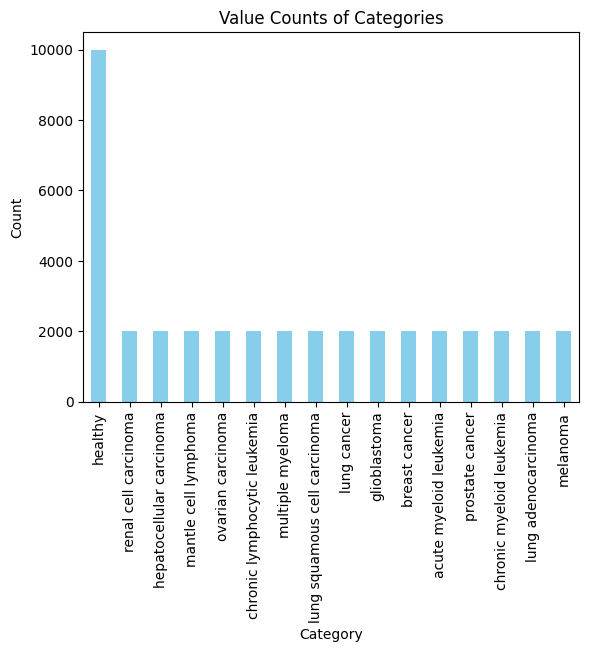

In [4]:
tissue_counts = overall_df['Disease'].value_counts()
tissue_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Value Counts of Categories')
plt.show()


In [5]:
tissues = overall_df['Tissue'].unique()

for tissue in tissues:
    # 2. Filter the dataframe where the Tissue matches AND the Disease is 'healthy'
    healthy_tissue_df = overall_df[(overall_df['Tissue'] == tissue) & (overall_df['Disease'] == 'healthy')]
    
    # 3. Print the count
    print(f"Tissue: {tissue}, Healthy Count: {len(healthy_tissue_df)}, Total Count: {len(overall_df[overall_df['Tissue'] == tissue])}, Healthy Percentage: {len(healthy_tissue_df) / len(overall_df[overall_df['Tissue'] == tissue]) * 100:.2f}%")

Tissue: PBMC, Healthy Count: 0, Total Count: 10142, Healthy Percentage: 0.00%
Tissue: LYMPH_NODE, Healthy Count: 0, Total Count: 1458, Healthy Percentage: 0.00%
Tissue: KIDNEY, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: LIVER, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: OVARY, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: OTHER, Healthy Count: 10000, Total Count: 10000, Healthy Percentage: 100.00%
Tissue: SKIN, Healthy Count: 0, Total Count: 1082, Healthy Percentage: 0.00%
Tissue: LUNG, Healthy Count: 0, Total Count: 5311, Healthy Percentage: 0.00%
Tissue: BRAIN, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: MAMMA, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: PROSTATE, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: BONE_MARROW, Healthy Count: 0, Total Count: 3, Healthy Percentage: 0.00%


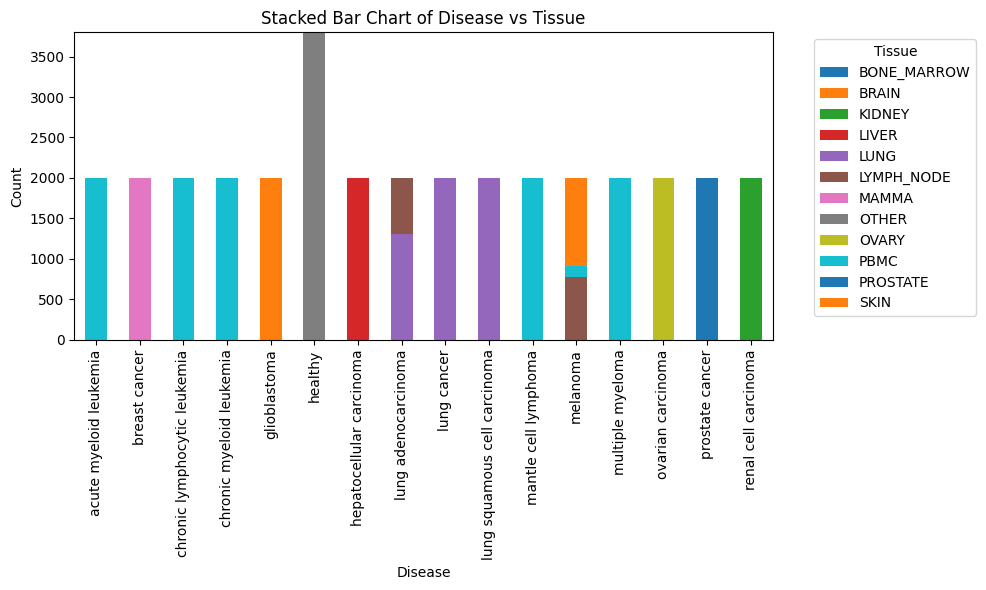

In [6]:
pd.crosstab(overall_df['Disease'], overall_df['Tissue']).sort_index(axis=0, ascending=True).plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Disease')
plt.ylabel('Count')
plt.ylim(0,3800)
plt.title('Stacked Bar Chart of Disease vs Tissue')
plt.legend(title='Tissue', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




In [1]:
%pip --version

pip 26.1.1 from /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pip (python 3.13)
Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
import requests
import py3Dmol
import numpy as np
import urllib3
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley

# 1. Suppress the annoying warnings from using verify=False
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# (Assuming 'data' is your pandas DataFrame loaded earlier)
# peptide_sequence = data.iloc[4]['Peptide Sequence'] 
peptide_sequence = "GILGFVFTL" # Hardcoded for testing
previous_peptide = None

output_dir = "Data/peptide_structures" 
os.makedirs(output_dir, exist_ok=True) 
pdb_filename = os.path.join(output_dir, f"{peptide_sequence}.pdb") 

# 2. Call API with a robust Session
def fetch_peptide_structure(sequence, filename):  
    url = "https://api.esmatlas.com/foldSequence/v1/pdb/"
    
    # Adding headers helps prevent load balancers from dropping the connection
    headers = {
        'Content-Type': 'text/plain',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'
    }
    
    # Set up a session with automatic retries for standard connection drops
    session = requests.Session()
    retries = Retry(total=3, backoff_factor=1, status_forcelist=[500, 502, 503, 504])
    session.mount('https://', HTTPAdapter(max_retries=retries))

    try: 
        response = session.post(url, data=sequence, headers=headers, verify=False, timeout=15)
        
        if response.status_code == 200:
            return response.text
        else:
            print(f"Server returned status code: {response.status_code}")
            return None
        
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        return None
    
if previous_peptide:
    print(previous_peptide)
    
print(f"Fetching structure for peptide: {peptide_sequence}...")
previous_peptide = peptide_sequence
pdb_data = fetch_peptide_structure(peptide_sequence, pdb_filename)

if pdb_data:
    # 3. Save Data
    with open(pdb_filename, "w") as f:
        f.write(pdb_data)
    print(f"Success! Saved to {pdb_filename}")

    # 4. VISUALIZE: Show 3D structure in VS Code / Jupyter
    view = py3Dmol.view(width=400, height=300)
    view.addModel(pdb_data, "pdb")
    view.setStyle({'model': -1}, {"cartoon": {'color': 'spectrum'}}) 
    view.zoomTo()
    view.show()

    # 5. ANALYZE: Calculate "Qualities" 
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("peptide", pdb_filename)

    # A. Radius of Gyration 
    atoms = list(structure.get_atoms())
    coords = np.array([atom.get_coord() for atom in atoms])
    center_of_mass = coords.mean(axis=0)
    rg = np.sqrt(np.sum((coords - center_of_mass)**2) / len(atoms))
    
    # B. SASA 
    sr = ShrakeRupley()
    sr.compute(structure, level="S") 
    total_sasa = structure.sasa
    
    # C. Confidence (pLDDT)
    b_factors = [atom.bfactor for atom in atoms]
    avg_plddt = sum(b_factors) / len(b_factors)

    print("-" * 30)
    print(f"FEATURE REPORT FOR {peptide_sequence}")
    print("-" * 30)
    print(f"1. Confidence (pLDDT): {avg_plddt:.2f} (0-100, >70 is good)")
    print(f"2. Radius of Gyration: {rg:.2f} Å (Lower = More Compact)")
    print(f"3. Total Surface Area: {total_sasa:.2f} Å²")
    print("-" * 30)

else:
    print("Failed to generate structure.")

Fetching structure for peptide: GILGFVFTL...
Success! Saved to Data/peptide_structures/GILGFVFTL.pdb


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

------------------------------
FEATURE REPORT FOR GILGFVFTL
------------------------------
1. Confidence (pLDDT): 0.65 (0-100, >70 is good)
2. Radius of Gyration: 5.43 Å (Lower = More Compact)
3. Total Surface Area: 1110.65 Å²
------------------------------


In [2]:
import os
import json
import requests
import py3Dmol
import numpy as np
import urllib3
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ─────────────────────────────────────────────
# HLA LIBRARY
# ─────────────────────────────────────────────

hla_library = {
    "HLA-A*24:02": (
        "GSHSMRYFSTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DEETGKVKAHSQTDRENLRIALRYYNQSEAGSHTLQMMFGCDVGSDGRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQITKRKWEAAHVAEQQRAYLEGTCVDGLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*02:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DGETRKVKAHSQTHRVDLGTLRGYYNQSEAGSHTVQRMYGCDVGSDWRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*32:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAHSQTDRESLRIALRYYNQSEAGSHTIQMMYGCDVGPDGRLLRGYQQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWEAARVAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWASVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*15:10": (
        "GSHSMRYFYTAMSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRNTQICKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQYAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-C*03:04": (
        "GSHSMRYFYTAVSRPGRGEPHFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVSLRNLRGYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLKNGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQWDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
    "HLA-C*14:02": (
        "CSHSMRYFSTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVSLRNLRGYYNQSEAGSHTLQWMFGCDLGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQRRAYLEGTCVEWLRRYLENGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQWDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
    "HLA-B*44:02": (
        "GSHSMRYFYTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRTALRYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQDRAYLEGLCVESLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEVTLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*57:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DGETRNMKASAQTYRENLRIALRYYNQSEAGSHIIQVMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*03:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQIMYGCDVGSDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAAHEAEQLRAYLDGTCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-C*05:01": (
        "CSHSMRYFYTAVSRPGRGEPRFIAVGYVDDTQFVQFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVNLRKLRGYYNQSEAGSHTLQRMYGCDLGPDGRLLRGYNQFAYDG"
        "KDYIALNEDLRSWTAADKAAQITQRKWEAAREAEQRRAYLEGTCVEWLRRYLENGKKTLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
    "HLA-B*27:05": (
        "GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRETQICKAKAQTDREDLRTLLRYYNQSEAGSHTLQNMYGCDVGPDGRLLRGYHQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGECVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*51:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQIFKTNTQTYRENLRIALRYYNQSEAGSHTWQTMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRHLENGKETLQ"
        "RADPPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*40:01": (
        "GSHSMRYFHTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLRSWTAADTAAQISQRKLEAARVAEQLRAYLEGECVEWLRRYLENGKDKLE"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*40:02": (
        "GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQSMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAARVAEQLRAYLEGECVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*07:02": (
        "GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRNTQIYKAQAQTDRESLRNLRGYYNQSEAGSHTLQSMYGCDVGPDGRLLRGHDQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQRRAYLEGECVEWLRRYLENGKDKLE"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*18:01": (
        "GSHSMRYFHTSVSRPGRGEPRFISVGYVDGTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGTCVEWLRRHLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*25:01": (
        "GSHSMRYFYTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DRNTRNVKAHSQTDRESLRIALRYYNQSEDGSHTIQRMYGCDVGPDGRFLRGYQQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWETAHEAEQWRAYLEGRCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWASVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*44:03": (
        "GSHSMRYFYTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRTALRYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVESLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEVTLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*30:01": (
        "GSHSMRYFSTSVSRPGSGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQERPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQIMYGCDVGSDGRFLRGYEQHAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWEAARWAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*11:01": (
        "GSHSMRYFYTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEDGSHTIQIMYGCDVGPDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAAHAAEQQRAYLEGRCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-C*12:03": (
        "CSHSMRYFYTAVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQADRVSLRNLRGYYNQSEAGSHTLQWMYGCDLGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQWRAYLEGTCVEWLRRYLENGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
    "HLA-B*49:01": (
        "GSHSMRYFHTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRIALRYYNQSEAGSHTWQRMYGCDLGPDGRLLRGYNQLAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*01:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQKMEPRAPWIEQEGPEYW"
        "DQETRNMKAHSQTDRANLGTLRGYYNQSEDGSHTIQIMYGCDVGPDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAVHAAEQRRVYLEGRCVDGLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*15:02": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DRNTQISKTNTQTYRESLRNLRGYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*35:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQIFKTNTQTYRESLRNLRGYYNQSEAGSHIIQRMYGCDLGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*68:02": (
        "GSHSMRYFYTSMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DRNTRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQRMYGCDVGPDGRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQWRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWVAVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*15:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQWRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
}

# ─────────────────────────────────────────────
# BETA-2 MICROGLOBULIN
# ─────────────────────────────────────────────

B2M_SEQ = (
    "MSRSVALAVLALLSLSGLEAIQRTPKIQVYSRHPAENGKSNFLNCYVSGFHPSDIEVDLL"
    "KNGERIEKVEHSDLSFSKDWSFYLLYYTEFTPTEKDEYACRVNHVTLSQPKIVKWDRDM"
)

# ─────────────────────────────────────────────
# ESMFOLD API
# ─────────────────────────────────────────────

# ESMFold only accepts a single unbroken amino acid sequence (no chain
# separators). To fold the peptide and HLA heavy chain together — so
# that ESMFold models their interaction — we concatenate them with a
# short flexible GGGGS linker. The linker is chemically inert, lets
# the two domains fold independently, and is short enough not to
# dominate the structure. We track its length so we can split the
# output PDB back into the two original chains.

LINKER = "GGGGS"


def _esm_post(sequence, timeout=120):
    """POST a single sequence to ESMFold. Returns PDB text or None."""
    url = "https://api.esmatlas.com/foldSequence/v1/pdb/"
    session = requests.Session()
    retries = Retry(total=3, backoff_factor=2,
                    status_forcelist=[500, 502, 503, 504])
    session.mount("https://", HTTPAdapter(max_retries=retries))
    try:
        r = session.post(
            url, data=sequence,
            headers={"Content-Type": "text/plain", "User-Agent": "Mozilla/5.0"},
            verify=False, timeout=timeout,
        )
        if r.status_code == 200:
            return r.text
        print(f"[ESMFold] HTTP {r.status_code}: {r.text[:200]}")
    except requests.exceptions.RequestException as e:
        print(f"[ESMFold] Request failed: {e}")
    return None


def _split_pdb_chains(pdb_text, peptide_len, linker_len):
    """
    ESMFold returns a single-chain PDB (chain A throughout).
    This function relabels residues:
      - residues 1 .. peptide_len            → chain A  (peptide)
      - residues peptide_len+1 .. +linker_len → chain L  (linker, kept for
                                                           completeness but
                                                           not analysed)
      - remaining residues                   → chain B  (HLA heavy chain)

    Returns the modified PDB text.
    """
    new_lines = []
    for line in pdb_text.splitlines(keepends=True):
        if line.startswith(("ATOM", "HETATM")):
            try:
                res_seq = int(line[22:26].strip())
            except ValueError:
                new_lines.append(line)
                continue

            if res_seq <= peptide_len:
                chain_id = "A"
            elif res_seq <= peptide_len + linker_len:
                chain_id = "L"
            else:
                chain_id = "B"

            line = line[:21] + chain_id + line[22:]
        new_lines.append(line)
    return "".join(new_lines)


# ─────────────────────────────────────────────
# MAIN FOLDING FUNCTION
# ─────────────────────────────────────────────

def fold_pmhc_complex(peptide_seq, hla_allele,
                      output_dir="Data/peptide_structures"):
    """
    Folds the peptide + HLA heavy chain together using ESMFold.

    Strategy
    --------
    ESMFold requires a single continuous sequence. We concatenate:

        <peptide> + GGGGS (linker) + <HLA heavy chain>

    and send this as one string. ESMFold folds the entire construct
    simultaneously, capturing contacts between the peptide and the
    HLA groove. After folding we relabel the output PDB so that:

        Chain A = peptide residues
        Chain L = linker  (ignored in analysis)
        Chain B = HLA heavy chain residues

    Parameters
    ----------
    peptide_seq : str  – peptide amino acid sequence
    hla_allele  : str  – key from hla_library, e.g. "HLA-A*02:01"
    output_dir  : str  – directory to save PDB files

    Returns
    -------
    (pdb_path, pdb_text)  or  None on failure
    """
    if hla_allele not in hla_library:
        raise ValueError(
            f"'{hla_allele}' not found in hla_library.\n"
            f"Available: {list(hla_library.keys())}"
        )

    hla_seq  = hla_library[hla_allele]
    combined = peptide_seq + LINKER + hla_seq
    total_aa = len(combined)

    print(f"\n[ESMFold] Folding pMHC complex")
    print(f"          Peptide : {peptide_seq}  ({len(peptide_seq)} aa)  → chain A")
    print(f"          Linker  : {LINKER}  ({len(LINKER)} aa)           → chain L (discarded)")
    print(f"          HLA     : {hla_allele}  ({len(hla_seq)} aa)  → chain B")
    print(f"          Total   : {total_aa} aa sent to ESMFold")
    print(f"          Waiting for ESMFold response …")

    pdb_raw = _esm_post(combined)
    if not pdb_raw:
        print("[ESMFold] Failed – no structure returned.")
        return None

    # Relabel chains in the returned PDB
    pdb_text = _split_pdb_chains(pdb_raw, len(peptide_seq), len(LINKER))

    os.makedirs(output_dir, exist_ok=True)
    safe_allele = hla_allele.replace("*", "").replace(":", "")
    pdb_path    = os.path.join(output_dir, f"{safe_allele}_{peptide_seq}_complex.pdb")

    with open(pdb_path, "w") as f:
        f.write(pdb_text)
    print(f"[ESMFold] PDB saved → {pdb_path}")

    return pdb_path, pdb_text


# ─────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────

def visualize_pmhc(pdb_text, width=700, height=500):
    """
    Renders the pMHC complex in py3Dmol:
      Chain A (peptide)   → red sticks + thin cartoon
      Chain B (HLA heavy) → spectrum cartoon
      Chain L (linker)    → hidden
    """
    view = py3Dmol.view(width=width, height=height)
    view.addModel(pdb_text, "pdb")

    # HLA heavy chain
    view.setStyle({"chain": "B"}, {"cartoon": {"color": "spectrum"}})

    # Peptide – red sticks so it stands out in the groove
    view.setStyle({"chain": "A"}, {
        "stick":   {"color": "red", "radius": 0.25},
        "cartoon": {"color": "red"},
    })

    # Hide linker
    view.setStyle({"chain": "L"}, {})

    view.zoomTo()
    view.show()


# ─────────────────────────────────────────────
# STRUCTURAL ANALYSIS
# ─────────────────────────────────────────────

def analyze_complex(pdb_path):
    """
    Returns per-chain and overall pLDDT, radius of gyration, and SASA.
    Linker residues (chain L) are excluded from all metrics.
    """
    parser    = PDBParser(QUIET=True)
    structure = parser.get_structure("pmhc", pdb_path)

    all_atoms     = [a for a in structure.get_atoms()
                     if a.get_full_id()[2] != "L"]
    peptide_atoms = [a for a in all_atoms if a.get_full_id()[2] == "A"]
    hla_atoms     = [a for a in all_atoms if a.get_full_id()[2] == "B"]

    def mean_plddt(atoms):
        return float(np.mean([a.bfactor for a in atoms])) if atoms else 0.0

    coords = np.array([a.get_coord() for a in all_atoms])
    center = coords.mean(axis=0)
    rg     = float(np.sqrt(np.mean(np.sum((coords - center) ** 2, axis=1))))

    sr = ShrakeRupley()
    sr.compute(structure, level="S")
    total_sasa = structure.sasa

    return {
        "plddt_overall": mean_plddt(all_atoms),
        "plddt_peptide": mean_plddt(peptide_atoms),
        "plddt_hla":     mean_plddt(hla_atoms),
        "rg":            rg,
        "sasa":          total_sasa,
    }


def print_report(metrics, peptide_seq, hla_allele):
    sep = "─" * 48
    print(f"\n{sep}")
    print(f"  COMPLEX REPORT: {hla_allele}  +  {peptide_seq}")
    print(sep)
    print(f"  Overall pLDDT  : {metrics['plddt_overall']:.2f}  (>70 = reliable)")
    print(f"  Peptide pLDDT  : {metrics['plddt_peptide']:.2f}  (confidence in groove)")
    print(f"  HLA pLDDT      : {metrics['plddt_hla']:.2f}")
    print(f"  Radius of Gyr. : {metrics['rg']:.2f} Å")
    print(f"  Total SASA     : {metrics['sasa']:.2f} Å²")
    print(sep)


# ─────────────────────────────────────────────
# AF3 JSON  (optional high-accuracy follow-up)
# ─────────────────────────────────────────────

def generate_af3_json(peptide_seq, hla_allele,
                      job_name=None, output_dir="Data/af3_inputs"):
    """
    Writes an AlphaFold 3 input JSON for the full pMHC trimer
    (peptide + HLA heavy chain + B2M) for submission to
    https://alphafoldserver.com

    No linker is used here — AF3 handles multi-chain inputs natively.
    """
    if hla_allele not in hla_library:
        raise ValueError(f"'{hla_allele}' not in hla_library.")

    if job_name is None:
        safe = hla_allele.replace("*", "").replace(":", "")
        job_name = f"{safe}_{peptide_seq}"

    sequences = [
        {"protein": {"id": "A", "sequence": peptide_seq}},
        {"protein": {"id": "B", "sequence": hla_library[hla_allele]}},
        {"protein": {"id": "C", "sequence": B2M_SEQ}},
    ]
    af3_input = {"name": job_name, "modelSeeds": [42], "sequences": sequences}

    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"{job_name}_af3_input.json")
    with open(out_path, "w") as f:
        json.dump(af3_input, f, indent=4)

    print(f"[AF3]  JSON → {out_path}  (upload to alphafoldserver.com)")
    return out_path


# ─────────────────────────────────────────────
# PIPELINE ENTRY POINT
# ─────────────────────────────────────────────

def run_pipeline(peptide_seq, hla_allele,
                 output_dir="Data/peptide_structures",
                 af3_output_dir="Data/af3_inputs",
                 generate_af3=True):
    """
    Full pipeline for one peptide + HLA allele pair:

      1. Concatenates  peptide + GGGGS + HLA heavy chain
      2. Sends to ESMFold → gets back a single PDB
      3. Relabels PDB chains: peptide=A, linker=L, HLA=B
      4. Saves PDB to output_dir
      5. Visualises (peptide in red, HLA in spectrum, linker hidden)
      6. Reports pLDDT / Rg / SASA (linker excluded)
      7. Optionally writes an AF3 JSON for high-accuracy follow-up

    Parameters
    ----------
    peptide_seq   : str  – amino acid sequence of the peptide
    hla_allele    : str  – key from hla_library, e.g. "HLA-A*02:01"
    output_dir    : str  – where to save PDB files
    af3_output_dir: str  – where to save AF3 JSON files
    generate_af3  : bool – also write an AF3 JSON
    """
    print("=" * 50)
    print(f"  PIPELINE  {hla_allele}  +  {peptide_seq}")
    print("=" * 50)

    result = fold_pmhc_complex(peptide_seq, hla_allele, output_dir)
    if result is None:
        print("Pipeline aborted.")
        return None
    pdb_path, pdb_text = result

    visualize_pmhc(pdb_text)

    metrics = analyze_complex(pdb_path)
    print_report(metrics, peptide_seq, hla_allele)

    af3_path = None
    if generate_af3:
        af3_path = generate_af3_json(peptide_seq, hla_allele,
                                     output_dir=af3_output_dir)

    return {"pdb_path": pdb_path, "metrics": metrics, "af3_json": af3_path}


# ─────────────────────────────────────────────
# EXAMPLE USAGE
# ─────────────────────────────────────────────

if __name__ == "__main__":

    # Single run
    run_pipeline(
        peptide_seq = "GILGFVFTL",   # Influenza A Matrix peptide
        hla_allele  = "HLA-A*02:01"
    )

    # Batch: same peptide across multiple alleles
    # for allele in ["HLA-A*02:01", "HLA-B*57:01", "HLA-C*03:04"]:
    #     run_pipeline("GILGFVFTL", allele)

  PIPELINE  HLA-A*02:01  +  GILGFVFTL

[ESMFold] Folding pMHC complex
          Peptide : GILGFVFTL  (9 aa)  → chain A
          Linker  : GGGGS  (5 aa)           → chain L (discarded)
          HLA     : HLA-A*02:01  (274 aa)  → chain B
          Total   : 288 aa sent to ESMFold
          Waiting for ESMFold response …
[ESMFold] PDB saved → Data/peptide_structures/HLA-A0201_GILGFVFTL_complex.pdb


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


────────────────────────────────────────────────
  COMPLEX REPORT: HLA-A*02:01  +  GILGFVFTL
────────────────────────────────────────────────
  Overall pLDDT  : 0.85  (>70 = reliable)
  Peptide pLDDT  : 0.48  (confidence in groove)
  HLA pLDDT      : 0.86
  Radius of Gyr. : 22.87 Å
  Total SASA     : 16513.96 Å²
────────────────────────────────────────────────
[AF3]  JSON → Data/af3_inputs/HLA-A0201_GILGFVFTL_af3_input.json  (upload to alphafoldserver.com)


In [19]:
%pip install --upgrade numpy

  Using cached numpy-2.4.6-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp313-cp313-macosx_14_0_arm64.whl (5.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bioservices 1.16.0 requires numpy<2.4,>=1.23.2, but you have numpy 2.4.6 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.6 which is incompatible.
graphein 1.7.8 requires numpy<2, but you have numpy 2.4.6 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [4]:
from graphein.protein.config import ProteinGraphConfig
from graphein.protein.graphs import construct_graph

# Load the default config
path = "/Users/akhil/vscode/Peptides/Notebooks/Data/pmhc_structures/HLA-A0201_GILGFVFTL_complex.pdb"

c = ProteinGraphConfig(granularity='CA', pdb_dir=path)


# Construct the graph!
g = construct_graph(path = path)

from graphein.protein.visualisation import plotly_protein_structure_graph

plotly_protein_structure_graph(g, node_size_multiplier=0.5, colour_nodes_by="residue_name")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hoverinfo': 'text+x+y+z',
              'marker': {'color': [[np.float64(0.631017), np.float64(0.107699),
                                   np.float64(0.608287), np.float64(1.0)],
                                   [np.float64(0.748289), np.float64(0.222711),
                                   np.float64(0.516834), np.float64(1.0)],
                                   [np.float64(0.798216), np.float64(0.280197),
                                   np.float64(0.469538), np.float64(1.0)], ...,
                                   [np.float64(0.631017), np.float64(0.107699),
                                   np.float64(0.608287), np.float64(1.0)],
                                   [np.float64(0.631017), np.float64(0.107699),
                                   np.float64(0.608287), np.float64(1.0)],
                                   [np.float64(0.973416), np.float64(0.585761),
                                   np.float64(0.25154), np.float64(1.0)]],
                         'opacity': 0.7,
                         'size': [20.5, 21.0, 21.0, ..., 21.0, 21.0, 20.5],
                         'symbol': 'circle'},
              'mode': 'markers',
              'text': [A:GLY:1, A:ILE:2, A:LEU:3, ..., L:GLY:12, L:GLY:13,
                       L:SER:14],
              'type': 'scatter3d',
              'x': [8.529999732971191, 6.514999866485596, 5.2820000648498535, ...,
                    -2.4570000171661377, -1.7690000534057617, -1.1740000247955322],
              'y': [3.7829999923706055, 2.0789999961853027, 5.4019999504089355,
                    ..., 4.285999774932861, 5.863999843597412, 3.109999895095825],
              'z': [-16.009000778198242, -13.28600025177002, -11.730999946594238,
                    ..., 11.206999778747559, 14.616000175476074,
                    17.187000274658203]},
             {'hoverinfo': 'text',
              'line': {'color': [[np.float64(0.050383), np.float64(0.029803),
                                 np.float64(0.527975), 1.0], [np.float64(0.050383),
                                 np.float64(0.029803), np.float64(0.527975), 1.0],
                                 [np.float64(0.050383), np.float64(0.029803),
                                 np.float64(0.527975), 1.0], ...,
                                 [np.float64(0.050383), np.float64(0.029803),
                                 np.float64(0.527975), 1.0], [np.float64(0.050383),
                                 np.float64(0.029803), np.float64(0.527975), 1.0],
                                 [np.float64(0.050383), np.float64(0.029803),
                                 np.float64(0.527975), 1.0]],
                       'width': 10},
              'mode': 'lines',
              'text': array(['peptide_bond', 'peptide_bond', 'peptide_bond', ..., 'peptide_bond',
                             'peptide_bond', 'peptide_bond'], shape=(855,), dtype=object),
              'type': 'scatter3d',
              'x': [8.529999732971191, 6.514999866485596, None, ...,
                    -1.7690000534057617, -1.1740000247955322, None],
              'y': [3.7829999923706055, 2.0789999961853027, None, ...,
                    5.863999843597412, 3.109999895095825, None],
              'z': [-16.009000778198242, -13.28600025177002, None, ...,
                    14.616000175476074, 17.187000274658203, None]}],
    'layout': {'height': 650,
               'margin': {'t': 100},
               'scene': {'xaxis': {'showbackground': False,
                                   'showgrid': False,
                                   'showline': False,
                                   'showticklabels': False,
                                   'title': {'text': ''},
                                   'zeroline': False},
                         'yaxis': {'showbackground': False,
                                   'showgrid': False,
                                   'showline': False,
                                   'showticklabels': False,
    

In [5]:
# Assuming 'G' is your Graphein-generated NetworkX graph
global_attributes = g.graph

# Example: Extracting the protein's PDB identifier
pdb_id = global_attributes.get("pdb_id")
print("Global Context (PDB ID):", pdb_id)

# Extract all nodes and their features
all_nodes = g.nodes(data=True)

# Iterate through nodes to extract specific features
for node_id, node_features in all_nodes:
    residue_name = node_features.get("residue_name")
    coords = node_features.get("coords") # 3D spatial coordinates
    print(f"Node {node_id}: {residue_name} at {coords}")


# Extract all edges and their features
all_edges = g.edges(data=True)

# Iterate through edges to extract specific relationship data
for node_u, node_v, edge_features in all_edges:
    distance = edge_features.get("distance")
    bond_type = edge_features.get("kind") 
    print(f"Edge between {node_u} and {node_v} is of type {bond_type} (Distance: {distance})")

Global Context (PDB ID): None
Node A:GLY:1: GLY at [  8.53    3.783 -16.009]
Node A:ILE:2: ILE at [  6.515   2.079 -13.286]
Node A:LEU:3: LEU at [  5.282   5.402 -11.731]
Node A:GLY:4: GLY at [ 5.323  4.328 -8.137]
Node A:PHE:5: PHE at [ 2.19   5.63  -6.561]
Node A:VAL:6: VAL at [ 3.776  6.976 -3.477]
Node A:PHE:7: PHE at [ 0.793  6.194 -1.371]
Node A:THR:8: THR at [1.641 7.882 1.76 ]
Node A:LEU:9: LEU at [0.435 5.005 3.812]
Node B:GLY:15: GLY at [-4.303  1.135 16.772]
Node B:SER:16: SER at [-5.689  1.663 13.366]
Node B:HIS:17: HIS at [-5.847 -1.168 10.844]
Node B:SER:18: SER at [-6.422 -1.112  7.097]
Node B:MET:19: MET at [-7.555 -3.439  4.331]
Node B:ARG:20: ARG at [-6.665 -2.468  0.773]
Node B:TYR:21: TYR at [-6.934 -3.895 -2.679]
Node B:PHE:22: PHE at [-4.973 -2.819 -5.698]
Node B:PHE:23: PHE at [-6.11  -3.705 -9.184]
Node B:THR:24: THR at [ -4.011  -3.115 -12.305]
Node B:SER:25: SER at [ -4.949  -3.791 -15.873]
Node B:VAL:26: VAL at [ -2.457  -3.312 -18.732]
Node B:SER:27: SER at 